<a href="https://colab.research.google.com/github/LSim2002/Binance_signal_discovery/blob/main/Binance_alpha_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIM of this project

The goal is not:

Find a universal law of markets.

The goal is:

Find a statistically reliable niche.

In [54]:
# Imports

In [55]:
import time
import requests
import pandas as pd
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import copy
import matplotlib.pyplot as plt
import torch.optim as optim
from tqdm.notebook import tqdm
from google.colab import files
import seaborn as sns
from sklearn.metrics import matthews_corrcoef
import math
from datetime import datetime, timezone

In [56]:

print(torch.cuda.is_available())

True


# Util functions

In [57]:




def get_targets_array(loader):
    targets = []
    for _, y_batch in loader:
        targets.append(y_batch)
    return torch.cat(targets, dim=0).numpy().ravel()


def destandardize(arr, y_mean, y_std):
    return arr * y_std + y_mean



# Data prep

input X_t:
[lookback, nb_symbols * nb_features]

For now, we use only one feature: pct returns between ticks.

target y_t:
[nb_symbols]

y_t = close[t + horizon] / close[t] - 1


## Get close prices of a given pair  

In [58]:
klines_rest_url = "https://api.binance.com/api/v3/klines"

In [89]:
#test api

params = {
    "symbol": "BTCUSDT",
    "interval": "1m",
    "startTime": 1704067200000,
    "endTime": 1704153600000,
    "limit": 1000
}
data = requests.get(klines_rest_url, params=params).json()
#print(data)
#print([[candle[4], candle[6]] for candle in data]) #close price and close time

In [60]:
#this should be the only place where we use timestamps (but datetimes as args and as output, just ts for the requests inside the function)
def get_symbol_data(symbol: str, interval: str, data_start_datetime: datetime, data_end_datetime: datetime, verbose=False):
    """
    Gets close price, volume, number of trades, and taker buy base asset volume
    between start time and end time with provided granularity.

    Parameters
    ----------
    symbol : str
        Exemple: "BTCUSDT"
    interval : str
        Exemple: "1m", "5m", "1h", "1d"
    data_start_datetime, data_end_datetime : datetime
        Datetime objects (assumed UTC).

    Returns
    -------
    Returns a df indexed by close time, cols are
        - {symbol}_close
        - {symbol}_volume
        - {symbol}_n_trades
        - {symbol}_taker_buy_volume
    the first tick will have close_time = start + interval - 1ms
    the last one will have end - 1ms
    """

    st = int(data_start_datetime.timestamp() * 1000)
    et = int(data_end_datetime.timestamp() * 1000)

    all_chunks = []  # each chunk is one request of max 1000 candles
    current_start = st
    if verbose == True:
        print(f"retrieving tick data for {symbol}")

    while current_start < et:  # might need to iterate because binance allows only 1000 ticks per request
        params = {
            "symbol": symbol.upper(),
            "interval": interval,
            "startTime": current_start,
            "endTime": et,
            "limit": 1000
        }

        r = requests.get(klines_rest_url, params=params, timeout=10)
        r.raise_for_status()
        data = r.json()
        #print(data)
        df_chunk = pd.DataFrame(data)[[6, 4, 5, 8, 9]]  # close_time, close, volume, n_trades, taker_buy_base_volume

        df_chunk.columns = [
            "close_time",
            f"{symbol}_close",
            f"{symbol}_volume",
            f"{symbol}_n_trades",
            f"{symbol}_taker_buy_volume",
        ]

        all_chunks.append(df_chunk)

        last_close_time = data[-1][6]
        current_start = last_close_time + 1

        time.sleep(0.05)  # just in case to respect req rate limit

    df = pd.concat(all_chunks, ignore_index=True)

    df[f"{symbol}_close"] = df[f"{symbol}_close"].astype(float)
    df[f"{symbol}_volume"] = df[f"{symbol}_volume"].astype(float)
    df[f"{symbol}_n_trades"] = df[f"{symbol}_n_trades"].astype(int)
    df[f"{symbol}_taker_buy_volume"] = df[f"{symbol}_taker_buy_volume"].astype(float)


    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)
    df.set_index("close_time", inplace=True)

    return df

##Concat close_dfs per symbol to get all_symbols_close_df
each column now has name "{SYMBOL}_close"

In [61]:
def concat_all_symbols_raw_data_df(close_dfs):
    """
    Parameters
    ----------
    close_dfs : list[pd.DataFrame]

    Returns a df indexed by close time, cols are
        - {symbol}_close
        - {symbol}_volume
        - {symbol}_n_trades
        - {symbol}_taker_buy_volume
    the first tick will have close_time = start + interval - 1ms
    the last one will have end - 1ms

    """
    all_symbols_raw_data_df = (
        pd.concat(close_dfs, axis=1)
        .sort_index()
        .dropna() #drops timestamps where one crypto is unavailable, shouldnt happen
    )

    return all_symbols_raw_data_df

##create features

In [62]:
def close_to_returns(close_df):
    return close_df / close_df.shift(1) - 1


def volume_to_volume_change(volume_df):
    return np.log1p(volume_df) - np.log1p(volume_df.shift(1))

def n_trades_to_trades_change(n_trades_df):
    return np.log1p(n_trades_df) - np.log1p(n_trades_df.shift(1))

def get_taker_buy_ratio(volume_df, taker_buy_volume_df):
    ratio = taker_buy_volume_df / volume_df
    return ratio.fillna(0)

def get_avg_trade_size(volume_df, n_trades_df):
    avg_size = volume_df / n_trades_df
    return avg_size.fillna(0)

def consecutive_inactive_streak(n_trades_df):
    """
    Length of the current consecutive run of zero-trade candles, ending at
    this candle (inclusive). 0 if this candle is active (n_trades > 0).
    Causal: uses only current and past values, no lookahead.
    """
    is_inactive = (n_trades_df == 0).astype(int)
    groups = (is_inactive != is_inactive.shift()).cumsum()
    streak = is_inactive.groupby(groups).cumcount() + 1
    streak = streak * is_inactive  # zero out active candles

    return streak


In [63]:
def make_features(all_symbols_df, symbols):
    """
    Builds the feature df from a multi-symbol df (output of get_data,
    concatenated across symbols), with columns named
    {symbol}_close, {symbol}_volume, {symbol}_n_trades, {symbol}_taker_buy_volume.

    All features at time t use only data available at close of candle t
    (no lookahead).

    Returns
    -------
    pd.DataFrame, one set of feature cols per symbol:
        {symbol}_return, {symbol}_volume_change,
        {symbol}_trades_change, {symbol}_taker_buy_ratio,
        {symbol}_avg_trade_size, {symbol}_consecutive_inactive_streak
        THERE WILL BE SOME NANS (just the first row)
    """
    feature_dfs = []

    for symbol in symbols:
        close = all_symbols_df[f"{symbol}_close"]
        volume = all_symbols_df[f"{symbol}_volume"]
        n_trades = all_symbols_df[f"{symbol}_n_trades"]
        taker_buy_volume = all_symbols_df[f"{symbol}_taker_buy_volume"]

        symbol_features = pd.DataFrame({
            f"{symbol}_return": close_to_returns(close),
            f"{symbol}_volume_change": volume_to_volume_change(volume),
            f"{symbol}_trades_change": n_trades_to_trades_change(n_trades),
            f"{symbol}_taker_buy_ratio": get_taker_buy_ratio(volume, taker_buy_volume),
            f"{symbol}_avg_trade_size": get_avg_trade_size(volume, n_trades),
            f"{symbol}_consecutive_inactive_streak": consecutive_inactive_streak(n_trades),
        })

        feature_dfs.append(symbol_features)

    features_df = pd.concat(feature_dfs, axis=1)

    return features_df #will have nans.

## create targets

In [64]:
def make_returns_at_horizon(all_symbols_raw_data_df, symbols, horizon):
    """
    Future returns: value at time t = close[t+horizon] / close[t] - 1.
    This is the prediction target. Looks into the future (by design),
    so it must NEVER be used as a feature — only as y.

    The last `horizon` rows will be NaN (no t+horizon available yet).
    """
    target_dfs = []

    for symbol in symbols:
        close = all_symbols_raw_data_df[f"{symbol}_close"]
        future_return = close.shift(-horizon) / close - 1
        target_dfs.append(future_return.rename(f"{symbol}_future_return_h{horizon}"))

    returns_at_horizon_df = pd.concat(target_dfs, axis=1)

    return returns_at_horizon_df

## get X and y for lstm training

In [65]:
def features_and_future_returns_to_X_y(features_df, future_returns_df, lookback, horizon):
    """
    features_df:
        index = close_time (datetime, UTC)
        columns = feature cols (output of make_features, e.g. {symbol}_return,
                  {symbol}_volume_change, ..., for all symbols)

    future_returns_df:
        index = close_time (datetime, UTC)
        columns = {symbol}_future_return (output of make_returns_at_horizon)

    X shape: [n_samples, lookback, n_features]
    y shape: [n_samples, n_targets]
    """
    n = len(features_df)
    assert len(future_returns_df) == n, "features_df and future_returns_df must have the same length"
    assert (features_df.index == future_returns_df.index).all(), "features_df and future_returns_df must share the same index"

    n_features = features_df.shape[1]
    n_targets = future_returns_df.shape[1]

    features_nan_idx = features_df[features_df.isna().any(axis=1)].index
    future_nan_idx = future_returns_df[future_returns_df.isna().any(axis=1)].index

    assert len(features_nan_idx) == 1, f"length of features NaN timestamps should be 1, got {len(features_nan_idx)}"
    assert len(future_nan_idx) == horizon, f"length of future returns NaN timestamps should be {horizon}, got {len(future_nan_idx)}"

    invalid_idx = features_nan_idx.union(future_nan_idx)

    features_df = features_df.drop(index=invalid_idx)  # CLIPPED
    future_returns_df = future_returns_df.drop(index=invalid_idx)

    assert features_df.shape == (n - horizon - 1, n_features), f"clipped features shape should be (n-h-1, n_features), currently {features_df.shape}"
    assert future_returns_df.shape == (n - horizon - 1, n_targets), f"clipped future returns shape should be (n-h-1, n_targets), currently {future_returns_df.shape}"
    assert features_df.shape[0] >= lookback, f"Need at least {lookback} valid rows to create one window, got {features_df.shape[0]}"

    # make into numpy arrays
    features_values = features_df.values
    future_returns_values = future_returns_df.values

    X = sliding_window_view(features_values, window_shape=lookback, axis=0)
    assert X.shape == (n - horizon - 1 - lookback + 1, n_features, lookback), \
        "X shape should be (n-h-1-lookback+1, n_features, lookback)"

    X = np.transpose(X, (0, 2, 1))
    assert X.shape == (n - horizon - 1 - lookback + 1, lookback, n_features), \
        "transposed X shape should be (n-h-1-lookback+1, lookback, n_features)"

    y = future_returns_values[lookback - 1:]  # remove the first future returns that are unusable bc of lookback
    assert y.shape == (n - horizon - 1 - lookback + 1, n_targets), "y shape should be (n-h-1-lb+1, n_targets)"

    # X and y should now have same first dimension
    # and we should have X[0] <-> y[0]
    # X[1] <-> y[1]
    # etc...

    datetimes = features_df.index[lookback - 1:]  # or future_returns_df.index[lookback - 1:]

    assert len(datetimes) == len(X) == len(y)

    return X, y, datetimes

## split train val test
shuffle is within train not before split!

In [66]:
def train_val_test_split_by_date(X, y, datetimes, test_start_datetime, test_end_datetime, val_ratio=0.10):
    """
    test: test_start_datetime <= datetimes < test_end_datetime (fixed, uncontaminated)
    train/val: everything before test_start_datetime, split chronologically by val_ratio
               (val = the most recent val_ratio fraction of the train_val data)
    """


    train_val_mask = datetimes  < test_start_datetime
    test_mask = (datetimes  >= test_start_datetime) & (datetimes  < test_end_datetime)

    n_train_val = train_val_mask.sum()
    n_val = int(n_train_val * val_ratio)
    train_end_idx = n_train_val - n_val  # index within the train_val slice

    X_train_val, y_train_val, dt_train_val = X[train_val_mask], y[train_val_mask], datetimes[train_val_mask]

    X_train, y_train, dt_train = X_train_val[:train_end_idx], y_train_val[:train_end_idx], dt_train_val[:train_end_idx]
    X_val, y_val, dt_val = X_train_val[train_end_idx:], y_train_val[train_end_idx:], dt_train_val[train_end_idx:]

    X_test, y_test, dt_test = X[test_mask], y[test_mask], datetimes[test_mask]

    assert len(X_train) > 0, "Train set is empty — check test_start_datetime/val_ratio."
    assert len(X_val) > 0, "Val set is empty — check val_ratio."
    assert len(X_test) > 0, "Test set is empty — check test_start_datetime/test_end_datetime vs data range."

    return (
        X_train, y_train, dt_train,
        X_val, y_val, dt_val,
        X_test, y_test, dt_test
    )

## Standardise

In [67]:
def standardize_X_y(X_train, y_train,X_val, y_val,X_test, y_test,eps=1e-8):
    """
    X shape: [n_samples, lookback, n_symbols]
    y shape: [n_samples, n_symbols]
    """
    #print("\n Statistics before standardization")

    #print_standardization_report(X_train, y_train,X_val, y_val,X_test, y_test,symbols)



    # X statistics (symbol-wise)
    X_mean = X_train.mean(axis=(0, 1), keepdims=True)
    X_std = X_train.std(axis=(0, 1), keepdims=True)
    X_std = np.maximum(X_std, eps)

    assert X_mean.shape == (1, 1, X_train.shape[2])
    assert X_std.shape == (1, 1, X_train.shape[2])


    # y statistics (symbol-wise)
    y_mean = y_train.mean(axis=0, keepdims=True)
    y_std = y_train.std(axis=0, keepdims=True)
    y_std = np.maximum(y_std, eps)

    assert y_mean.shape == (1, y_train.shape[1])
    assert y_std.shape == (1, y_train.shape[1])





    # normalize X
    X_train = (X_train - X_mean) / X_std
    X_val = (X_val - X_mean) / X_std
    X_test = (X_test - X_mean) / X_std

    # normalize y
    y_train = (y_train - y_mean) / y_std
    y_val = (y_val - y_mean) / y_std
    y_test = (y_test - y_mean) / y_std


    #print("\n Statistics after standardization")
    #print_standardization_report(X_train, y_train,X_val, y_val,X_test, y_test,symbols)

    return X_train, y_train,X_val, y_val,X_test, y_test, y_mean, y_std


In [68]:
def print_standardization_report(X_train, y_train,X_val, y_val,X_test, y_test,symbols):
    X_stats = pd.DataFrame(
        {
            "X_train_mean": X_train.mean(axis=(0, 1)),
            "X_train_std": X_train.std(axis=(0, 1)),
            "X_val_mean": X_val.mean(axis=(0, 1)),
            "X_val_std": X_val.std(axis=(0, 1)),
            "X_test_mean": X_test.mean(axis=(0, 1)),
            "X_test_std": X_test.std(axis=(0, 1)),
        },
        index=symbols
    )

    y_stats = pd.DataFrame(
        {
            "y_train_mean": y_train.mean(axis=0),
            "y_train_std": y_train.std(axis=0),
            "y_val_mean": y_val.mean(axis=0),
            "y_val_std": y_val.std(axis=0),
            "y_test_mean": y_test.mean(axis=0),
            "y_test_std": y_test.std(axis=0),
        },
        index=symbols
    )

    display(X_stats)
    display(y_stats)

    #return X_stats, y_stats

## Create dataloaders

In [69]:
def create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=256):

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),torch.tensor(y_train, dtype=torch.float32))
    val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),torch.tensor(y_val, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),torch.tensor(y_test, dtype=torch.float32))

    train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True) # shuffle here)
    train_loader_inf = DataLoader(train_dataset,batch_size=batch_size,shuffle=False) # shuffle here)
    val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False) #could be true doesnt matter)
    test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False) #could be true doesnt matter)

    return train_loader, train_loader_inf, val_loader, test_loader

## lstm

In [70]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,      # n_symbols
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, output_size)  # output_size = n_symbols

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        last_hidden = lstm_out[:, -1, :]  # last timestep

        y_pred = self.fc(last_hidden)

        return y_pred

## run inference funct
we can give the output of this to a "get loss metrics" or whatever we want

In [71]:
def run_inference(model, loader, device="cpu"): #returns a 1d array (were working with single output models !!)

    model.to(device)
    model.eval()

    preds = []

    with torch.no_grad():

        for X_batch, _ in loader:

            X_batch = X_batch.to(device)

            y_pred = model(X_batch)

            preds.append(y_pred.cpu())
    return torch.cat(preds, dim=0).numpy().squeeze() #squeeze removes the output feature dimension since we only have 1 (predicted return for target stock)

## train loop
Optimize using criterion (mse for now)

Track:
- train mse loss
- val mse loss
- train corr
- val corr

In [72]:

#we will be returning and plotting the loss per symbol, BUT we are optimizing using MSE across all symbols (keep in mind)

def train_model(model, train_loader, train_loader_inf,  val_loader, criterion, optimizer, patience=5, device="cpu", verbose = False ):

    assert len(train_loader.dataset) != 0 and len(val_loader.dataset) != 0, "Skipping: train or val set is empty. Consider adding more data or reducing lookback/horizon."

    model.to(device)

    train_losses = []
    val_losses = []

    best_model_state_dict = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    epochs_without_improvement = 0


    epoch = 0
    while epochs_without_improvement < patience:

        # ==========================
        # TRAIN (optimizing for global loss accross all symbols - IF using multiple symbols in output! (which is no longer the case))
        # ==========================
        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

        # ==========================
        # GET LOSS AND CORR ON TRAIN SET AND VAL SET post epocH - stay in normalized space, thats what the optimizer is minimizing for
        # ==========================

        train_preds = run_inference(model, train_loader_inf, device) #1D np arr
        train_targets = get_targets_array(train_loader_inf)  #1D np arr
        curr_train_loss = criterion(torch.tensor(train_preds), torch.tensor(train_targets)).item() # a number - is the mse on train set AFTER epoch is over (not intra epoch train mse)
        train_losses.append(curr_train_loss)

        val_preds = run_inference(model, val_loader, device)
        val_targets = get_targets_array(val_loader)
        curr_val_loss = criterion(torch.tensor(val_preds), torch.tensor(val_targets)).item() # a number - is the mse on train set AFTER epoch is over (not intra epoch train mse)
        val_losses.append(curr_val_loss)


        # ==========================
        # CHECK FOR PATIENCE
        # ==========================

        if curr_val_loss < best_val_loss: #if currloss is  better
            epochs_without_improvement = 0
            best_val_loss = curr_val_loss
            best_model_state_dict = copy.deepcopy(model.state_dict())

        else:

            epochs_without_improvement += 1

        epoch += 1

        if verbose == True:
            print(f"\nEpoch {epoch} finished")
            print("curr Train loss: ", curr_train_loss)
            print("curr val loss: ", curr_val_loss)
            print("Number of epochs with No Improve: ",epochs_without_improvement)



    if verbose == True:
        print("\nStopping: patience reached ")

    model.load_state_dict(best_model_state_dict)
    return  model, train_losses, val_losses


## plot fct


In [73]:
def plot_curves(title, curves, curve_names, xlabel, ylabel,
    baseline_values=[],
    baseline_labels=[]):

    plt.figure(figsize=(6, 3))

    for curve, curve_name in zip(curves, curve_names):
        plt.plot(curve, label=curve_name)

    for value, label in zip(baseline_values,baseline_labels):
        plt.axhline( y=value,linestyle="--",label=label)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

## get zero baseline

In [74]:
def get_zero_baseline_loss(criterion, targets):
    targets = torch.tensor(targets, dtype=torch.float32)
    loss = criterion(torch.zeros_like(targets), targets)
    return loss.item()

## get naive momentum baseline

In [75]:
def test_naive_momentum_loss(criterion, targets):
    """
    Naive momentum baseline: predicts next return as the previous
    realized return (pred[i] = targets[i-1]). First point has no
    prior value, so it's dropped from comparison.
    """
    targets = torch.tensor(targets, dtype=torch.float32)

    preds = targets[:-1]      # shifted: yesterday's actual becomes today's prediction
    true = targets[1:]        # align targets to match shifted preds

    return criterion(preds, true).item()

## get oracle basline

In [76]:
def get_oracle_loss(criterion, targets, n):
    """
    Oracle baseline: a deliberately unfair, future-peeking upper bound.
    At index i, predicts the average of targets[i : i+n] (current point
    plus the next n-1 future returns), then compares against the actual
    target[i]. This cheats by using future information unavailable in
    real trading, so it should produce a much lower loss than any real
    model — useful as a ceiling to sanity-check how much headroom exists,
    not as something to beat.
    """
    targets = torch.tensor(targets, dtype=torch.float32)
    n_points = len(targets)

    if n_points < n:
        raise ValueError("targets shorter than window size n.")

    preds = torch.empty(n_points - n + 1)
    for i in range(n_points - n + 1):
        preds[i] = targets[i:i+n].mean()

    true = targets[:n_points - n + 1]

    return criterion(preds, true).item()

## get corr (pearson correlation)

In [77]:
def get_corr(preds, targets):
    return np.corrcoef(preds, targets)[0, 1]

##  get_pred_truth_std_ratio

In [78]:
def get_pred_truth_std_ratio(preds, targets):
    return preds.std() / targets.std()

## get mcc

In [79]:
def get_mcc(preds, targets):
    pred_sign = (preds > 0).astype(int)
    target_sign = (targets > 0).astype(int)
    return matthews_corrcoef(target_sign, pred_sign)

## plot performance heatmaps (lb, h)

In [80]:
def plot_heatmaps(df, n_cols=2, figsize_per_plot=(6, 5), save_path=None,
                   test_start_datetime=None, test_end_datetime=None):
    assert df["granularity"].nunique() == 1, "df contains multiple granularities — filter to one before plotting."
    assert df["symbol"].nunique() == 1, "df contains multiple symbols — filter to one before plotting."

    granularity = df["granularity"].iloc[0]
    target_symbol = df["symbol"].iloc[0]

    excluded_cols = {"granularity", "symbol", "lookback", "horizon", "target_symbol_idx"}
    metric_cols = [c for c in df.columns if c not in excluded_cols]

    n_metrics = len(metric_cols)
    n_rows = math.ceil(n_metrics / n_cols)
    figsize = (figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, metric in zip(axes, metric_cols):
        pivot = df.pivot(index="lookback", columns="horizon", values=metric)

        if "ratio" in metric:
            center, cmap = 1.0, "RdYlGn_r"
        else:
            center, cmap = 0.0, "RdYlGn"

        sns.heatmap(
            pivot, annot=True, fmt=".3f", cmap=cmap,
            center=center, ax=ax, cbar_kws={"label": metric}
        )
        ax.set_title(f"{metric}\n{granularity} / {target_symbol}")
        ax.set_xlabel("horizon")
        ax.set_ylabel("lookback")

    for ax in axes[n_metrics:]:
        ax.axis("off")

    # figure-level title showing the test window dates used
    if test_start_datetime is not None and test_end_datetime is not None:
        fig.suptitle(f"Test window: {test_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} → {test_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}", fontsize=12)


    plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room for suptitle

    if save_path is None:
        save_path = f"heatmap_{granularity}_{target_symbol} - {test_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {test_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    files.download(save_path)

## get returns above threshold

In [81]:
def get_returns_above_threshold(test_preds, test_targets, threshold, horizon):
    """
    test_preds: standardized space (same space the threshold was computed in)
    test_targets: denormalized space (true returns)
    threshold: standardized space, from get_val_threshold
    horizon: number of bars a position is held. Used to avoid flagging
        overlapping signals as separate trades — once a signal fires,
        the next (horizon - 1) bars are skipped, since you'd still be
        invested in the prior trade and couldn't act on them anyway.

    Returns (selected_returns, n_selected) — selected_returns are the
    realized returns for the non-overlapping selected entry points only.
    """
    mask = test_preds > threshold
    selected_indices = np.where(mask)[0]

    if len(selected_indices) == 0:
        return np.nan, 0

    # keep only non-overlapping signals: once a signal is taken,
    # skip any further signal within the next (horizon - 1) bars
    kept_indices = []
    last_taken = -np.inf
    for idx in selected_indices:
        if idx - last_taken >= horizon:
            kept_indices.append(idx)
            last_taken = idx

    n_selected = len(kept_indices)

    if n_selected == 0:
        return np.nan, 0

    return test_targets[kept_indices], n_selected

# Run experiments

## Main parameters


In [82]:
device = "cuda" if torch.cuda.is_available() else "cpu"

symbols = ["CRCLBUSDT", "NVDABUSDT","SNDKBUSDT","TSLABUSDT","MUBUSDT","BTCUSDT"] #were inputting multiple scmall cap cryptos AND BTC
n_symbols=len(symbols)
val_ratio = 0.10 #used always, because we only define test start and end by datetime to make sure no overlapping tests for reobust results
tf = 0.00075 #taker fee on binance
ROUND_TRIP_COST = 2 * 0.00075  # 0.0015 = 15 bps

## Plot performance in function of lb and h (single fold) (fixed granularity and target symbol)

In [83]:
def plot_lb_h_heatmaps(data_start_datetime, data_end_datetime, test_start_datetime, val_ratio, #fixed params
                   interval,target_symbol_idx, #semi fixed params
                   lookbacks,horizons): #search params


    num_experiments = len(lookbacks) * len(horizons)
    experiment_counter = 0
    results = []

    symbol_data_dfs = [ get_symbol_data(symbol, interval, data_start_datetime, data_end_datetime) for symbol in symbols ] #one df per symbol #LONG
    all_symbols_raw_data_df = concat_all_symbols_raw_data_df(symbol_data_dfs) #raw data for all symbols

    features_df = make_features(all_symbols_raw_data_df, symbols) #has nans at first row (FAST)


    for horizon in horizons: #iterate over horizons
        future_returns_df = make_returns_at_horizon(all_symbols_raw_data_df, symbols, horizon)

        for lookback in lookbacks: #iterate over lookbacks

            # Returns/targets are recomputed everytime since vectorized shifts/divisions are fast and vectorized, and memory is more valuable here.
            # instead of computing all X and y sets only once which would cost more memory
            X, y, datetimes = features_and_future_returns_to_X_y(features_df, future_returns_df, lookback, horizon)#slicing and converting to np arrays (FAST)
            #X,y are np arrays

            #split np arrays(FAST)
            X_train, y_train, dt_train, X_val, y_val, dt_val, X_test, y_test, dt_test = \
                train_val_test_split_by_date(X, y, datetimes, test_start_datetime, test_end_datetime = data_end_datetime, val_ratio=val_ratio) # single fold

            #standardize -vectorized (FAST)
            X_train, y_train,X_val, y_val,X_test, y_test, \
            y_mean, y_std = \
            standardize_X_y(X_train, y_train, X_val, y_val, X_test, y_test)
            y_mean_target = y_mean[0, target_symbol_idx]
            y_std_target = y_std[0, target_symbol_idx]

            #print stand report maybe
            #print_standardization_report(X_train, y_train,X_val, y_val,X_test, y_test,symbols)


            #slice y arrays (FAST) for target symbol
            y_train_target_symbol = y_train[:, target_symbol_idx:target_symbol_idx+1]
            y_val_target_symbol = y_val[:, target_symbol_idx:target_symbol_idx+1]
            y_test_target_symbol = y_test[:, target_symbol_idx:target_symbol_idx+1]

            #create loaders (FAST)
            train_loader, train_loader_inf, val_loader, test_loader = \
            create_dataloaders(X_train, y_train_target_symbol,X_val, y_val_target_symbol,X_test, y_test_target_symbol,batch_size=256)

            #init model (FAST)
            model = SimpleLSTM(input_size=X_train.shape[-1],hidden_size=128,output_size=1,num_layers=3)
            criterion = nn.MSELoss()
            optimizer = optim.Adam( model.parameters(), lr=1e-4 )

            assert len(train_loader.dataset) != 0 and len(val_loader.dataset) != 0, "Skipping: train or val set is empty. Consider adding more data or reducing lookback/horizon."

            #train model (can be long depending on granularity)
            model, train_losses, val_losses = train_model(model, train_loader, train_loader_inf, val_loader, criterion, optimizer, patience=10, device=device)

            #inference on test set (FAST)
            test_preds = run_inference(model, test_loader, device) #1d np array, not denormalized yet
            test_targets = get_targets_array(test_loader)            # 1d np array, standardized space
            denormed_test_preds = destandardize(test_preds, y_mean_target, y_std_target) #1d np array, destandardized
            denormed_test_targets = destandardize(test_targets, y_mean_target, y_std_target) #1d np array, destandardized


            #get metrics on test set
            test_zero_loss = get_zero_baseline_loss(criterion, denormed_test_targets)       # true zero-return baseline
            test_loss = criterion(torch.tensor(denormed_test_preds),torch.tensor(denormed_test_targets)).item()


            test_zero_loss_ratio = test_loss/test_zero_loss
            test_pred_truth_std_ratio = get_pred_truth_std_ratio(test_preds, test_targets)  # standardized, scale-invariant
            test_corr = get_corr(test_preds, test_targets)                                   # standardized, invariant to affine transformation
            test_mcc = get_mcc(denormed_test_preds, denormed_test_targets)                  # needs true sign, denorm required

            #will check conf directional conf matrix on case per case

            #store results:
            curr_results = {
                "granularity": interval,
                "lookback": lookback,
                "horizon": horizon,
                "target_symbol_idx": target_symbol_idx,
                "symbol": target_symbol,

                "test_zero_loss_ratio": test_zero_loss_ratio,
                "test_pred_truth_std_ratio": test_pred_truth_std_ratio,
                "test_corr": test_corr,
                "test_mcc": test_mcc,
            }
            results.append(curr_results)
            experiment_counter+=1
            print(f"experiment {experiment_counter}/{num_experiments} done, ({100 * experiment_counter / num_experiments:.1f}%)")


    experiment_results_df = (pd.DataFrame(results).sort_values(["test_zero_loss_ratio", "test_corr"], ascending=[True, False]))

    plot_heatmaps(experiment_results_df, n_cols=2, figsize_per_plot=(6, 5), save_path=None, test_start_datetime = test_start_datetime, test_end_datetime = data_end_datetime)

experiment 1/30 done, (3.3%)
experiment 2/30 done, (6.7%)
experiment 3/30 done, (10.0%)
experiment 4/30 done, (13.3%)
experiment 5/30 done, (16.7%)
experiment 6/30 done, (20.0%)
experiment 7/30 done, (23.3%)
experiment 8/30 done, (26.7%)
experiment 9/30 done, (30.0%)
experiment 10/30 done, (33.3%)
experiment 11/30 done, (36.7%)
experiment 12/30 done, (40.0%)
experiment 13/30 done, (43.3%)
experiment 14/30 done, (46.7%)
experiment 15/30 done, (50.0%)
experiment 16/30 done, (53.3%)
experiment 17/30 done, (56.7%)
experiment 18/30 done, (60.0%)
experiment 19/30 done, (63.3%)
experiment 20/30 done, (66.7%)
experiment 21/30 done, (70.0%)
experiment 22/30 done, (73.3%)
experiment 23/30 done, (76.7%)
experiment 24/30 done, (80.0%)
experiment 25/30 done, (83.3%)
experiment 26/30 done, (86.7%)
experiment 27/30 done, (90.0%)
experiment 28/30 done, (93.3%)
experiment 29/30 done, (96.7%)
experiment 30/30 done, (100.0%)


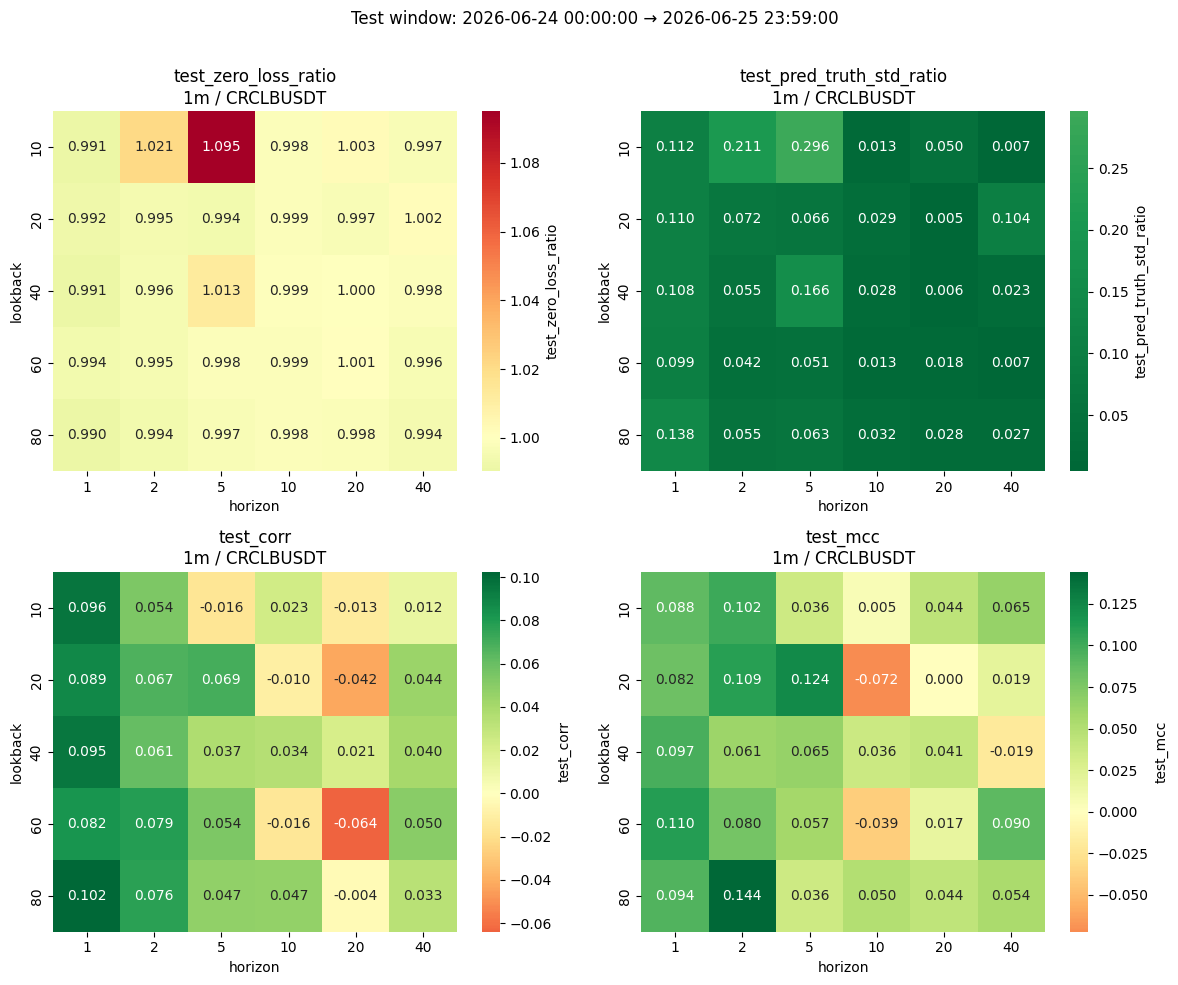

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:
#fixed params for parameter search
data_start_datetime = pd.Timestamp("2026-06-15 0:00:00", tz="UTC")
test_start_datetime = pd.Timestamp("2026-06-24 00:00:00", tz="UTC")
data_end_datetime = pd.Timestamp("2026-06-25 23:59:00", tz="UTC")



#semi fixed params for parameter search
interval = "1m" #granularity
target_symbol_idx = 0
target_symbol = symbols[target_symbol_idx]

#param search
lookbacks = [80, 60, 40, 20, 10] #[120,90,60,40,20,15,10,5]
horizons = [1,2,5,10,20,40] #[1,2,3,4,5,10,30,60]#

plot_lb_h_heatmaps(data_start_datetime, data_end_datetime, test_start_datetime, val_ratio, #fixed params
                   interval,target_symbol_idx, #semi fixed params
                   lookbacks,horizons) #search params

## Results from parameter search

we will move forward with horizon 1 or 2 for crclbusdt. lookback 60 looks alright.

## Run walk_forward_single_setup

In [85]:
def walk_forward_single_setup(data_start_datetime, data_end_datetime,
                               first_test_fold_start_datetime, n_test_folds,
                               lookback, horizon,
                               interval, target_symbol_idx,
                               val_ratio, threshold_percentile, verbose=True):
    """
    Rolling (fixed-size, non-expanding) walk-forward validation for a single
    (lookback, horizon) setup. Test period [first_test_fold_start_datetime, data_end_datetime]
    is split into n_test_folds equal folds. Each fold's train window has the
    same fixed duration (= first_test_fold_start_datetime - data_start_datetime),
    sliding forward fold by fold rather than expanding.
    """



    # fetch full-range data once
    symbol_data_dfs = [ get_symbol_data(symbol, interval, data_start_datetime, data_end_datetime) for symbol in symbols ] #one df per symbol #LONG
    all_symbols_raw_data_df = concat_all_symbols_raw_data_df(symbol_data_dfs) #raw data for all symbols
    features_df = make_features(all_symbols_raw_data_df, symbols) #has nans at first row (FAST)
    future_returns_df = make_returns_at_horizon(all_symbols_raw_data_df, symbols, horizon)


    X, y, datetimes = features_and_future_returns_to_X_y(features_df, future_returns_df, lookback, horizon)#slicing and converting to np arrays (FAST)

    target_symbol = symbols[target_symbol_idx]
    results = []

    all_returns_above_threshold = []   # pooled selected returns, all folds
    all_returns_unconditional = []     # pooled per-bar returns, all folds



    train_duration = first_test_fold_start_datetime - data_start_datetime #timedelta object
    total_test_duration = data_end_datetime - first_test_fold_start_datetime # timedelta
    fold_test_duration = total_test_duration / n_test_folds  # timedelta


    for fold_i in range(n_test_folds):
        test_start_datetime_i = first_test_fold_start_datetime + fold_i * fold_test_duration
        test_end_datetime_i = data_end_datetime if fold_i == n_test_folds - 1 else first_test_fold_start_datetime + (fold_i + 1) * fold_test_duration   # last fold absorbs any rounding remainder by going up to data_end_datetime
        train_window_start_datetime_i = test_start_datetime_i - train_duration


        fold_mask = (datetimes >= train_window_start_datetime_i) & (datetimes < test_end_datetime_i)
        X_fold, y_fold, ts_fold = X[fold_mask], y[fold_mask], datetimes[fold_mask]

        X_train, y_train, ts_train, X_val, y_val, ts_val, X_test, y_test, ts_test = \
            train_val_test_split_by_date(X_fold, y_fold, ts_fold, test_start_datetime_i, test_end_datetime_i, val_ratio=val_ratio)

        X_train, y_train, X_val, y_val, X_test, y_test, y_mean, y_std = \
            standardize_X_y(X_train, y_train, X_val, y_val, X_test, y_test)
        y_mean_target = y_mean[0, target_symbol_idx]
        y_std_target = y_std[0, target_symbol_idx]

        y_train_target = y_train[:, target_symbol_idx:target_symbol_idx + 1]
        y_val_target = y_val[:, target_symbol_idx:target_symbol_idx + 1]
        y_test_target = y_test[:, target_symbol_idx:target_symbol_idx + 1]

        train_loader, train_loader_inf, val_loader, test_loader = \
            create_dataloaders(X_train, y_train_target, X_val, y_val_target, X_test, y_test_target, batch_size=256)

        model = SimpleLSTM(input_size=X_train.shape[-1], hidden_size=128, output_size=1, num_layers=3)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-4)

        assert len(train_loader.dataset) != 0 and len(val_loader.dataset) != 0, \
            "Skipping: train or val set is empty for this fold."

        model, train_losses, val_losses = train_model(model, train_loader, train_loader_inf, val_loader, criterion, optimizer, patience=10, device=device)

        #get threshold for buy signal on val set
        val_preds = run_inference(model, val_loader, device)
        buy_threshold = np.percentile(val_preds, threshold_percentile) #threshold is in standardized space, USING 90% percentile threhsold
        if verbose==True:
            print("buy_threshold: ", buy_threshold)


        test_preds = run_inference(model, test_loader, device)
        test_targets = get_targets_array(test_loader)

        denormed_test_preds = destandardize(test_preds, y_mean_target, y_std_target)
        denormed_test_targets = destandardize(test_targets, y_mean_target, y_std_target)


        #get average return on test set
        average_return = denormed_test_targets.mean()
        all_returns_unconditional.append(denormed_test_targets.ravel())
        if verbose==True:
            print("average_return for current fold: ", average_return)
        returns_above_threshold, n_selected = get_returns_above_threshold(test_preds, denormed_test_targets, buy_threshold, horizon) #takes test preds in standardized space, but the mask is applied on denormed test targets
        if n_selected > 0:
            all_returns_above_threshold.append(np.asarray(returns_above_threshold).ravel())
        if verbose==True:
            print("average returns_above_threshold for current fold: ", np.nanmean(returns_above_threshold), "n_selected: ", n_selected)


        test_loss = criterion(torch.tensor(test_preds), torch.tensor(test_targets)).item()
        denormed_test_loss = criterion(torch.tensor(denormed_test_preds), torch.tensor(denormed_test_targets)).item()

        test_zero_loss_denormed = get_zero_baseline_loss(criterion, denormed_test_targets)
        test_zero_loss_ratio = denormed_test_loss / test_zero_loss_denormed

        naive_momentum_loss = test_naive_momentum_loss(criterion, test_targets)  # standardized space, same as model's test_loss
        momentum_loss_ratio = test_loss / naive_momentum_loss

        oracle_loss = get_oracle_loss(criterion, test_targets, n=5)
        oracle_loss_ratio = test_loss / oracle_loss #test_loss / oracle_loss

        test_pred_truth_std_ratio = get_pred_truth_std_ratio(test_preds, test_targets)
        test_corr = get_corr(test_preds, test_targets)
        test_mcc = get_mcc(denormed_test_preds, denormed_test_targets)

        results.append({
            "fold": fold_i,
            "test_fold_start": ts_test.min(),
            "test_fold_end": ts_test.max(),
            "lookback": lookback,
            "horizon": horizon,
            "symbol": target_symbol,


            "test_zero_loss_ratio": test_zero_loss_ratio,
            "momentum_loss_ratio": momentum_loss_ratio,
            "oracle_loss_ratio": oracle_loss_ratio,

            "test_pred_truth_std_ratio": test_pred_truth_std_ratio,
            "test_corr": test_corr,
            "test_mcc": test_mcc,

            "n_selected": n_selected,
            "mean_selected_return": np.nanmean(returns_above_threshold) if n_selected > 0 else np.nan,
            "mean_unconditional_return": average_return,


        })
        if verbose==True:
            print(f"fold {fold_i + 1}/{n_test_folds} done "
              f"({test_start_datetime_i.strftime('%Y-%m-%d %H:%M:%S')} → {test_end_datetime_i.strftime('%Y-%m-%d %H:%M:%S')})")


    ##end of the fold loop

    walk_forward_results_df = pd.DataFrame(results)


    # ---- pooled summary across all folds ----

    selected = np.concatenate(all_returns_above_threshold) if all_returns_above_threshold else np.array([])
    unconditional = np.concatenate(all_returns_unconditional)

    ROUND_TRIP_COST = 2 * 0.00075  # Binance taker, 15 bps round trip

    if verbose==True:
        print("\n" + "=" * 60)
        print(f"POOLED OVER {n_test_folds} FOLDS  |  lookback={lookback}  horizon={horizon}  "
            f"symbol={target_symbol}  percentile={threshold_percentile}")
        print("=" * 60)

        if selected.size > 0:
            mean_sel = selected.mean()
            std_sel = selected.std(ddof=1)
            se_sel = std_sel / np.sqrt(selected.size)
            print(f"selected trades      : n = {selected.size}")
            print(f"  mean selected return        : {mean_sel:.6e}  ({mean_sel * 1e4:.2f} bps)")
            print(f"  std  selected return        : {std_sel:.6e}  ({std_sel * 1e4:.2f} bps)")
            print(f"  std error of mean selected returns : {se_sel * 1e4:.2f} bps   (t = {mean_sel / se_sel:.2f})")
            print(f"  %% positive         : {100 * (selected > 0).mean():.1f}%")
        else:
            print("selected trades      : none")

        print(f"\nunconditional (all test bars): n = {unconditional.size}")
        print(f"  mean return        : {unconditional.mean():.6e}  ({unconditional.mean() * 1e4:.2f} bps)")
        print(f"  %% positive         : {100 * (unconditional > 0).mean():.1f}%")

        if selected.size > 0:
            edge = selected.mean() - unconditional.mean()
            print(f"\nconditional edge     : {edge * 1e4:.2f} bps  (selected − unconditional)")
            print(f"round-trip cost      : {ROUND_TRIP_COST * 1e4:.2f} bps  (2 x 7.5 bps taker)")
            print(f"net per trade        : {(selected.mean() - ROUND_TRIP_COST) * 1e4:.2f} bps")
            print(f"folds positive       : "
                f"{(walk_forward_results_df['mean_selected_return'] > 0).sum()}/{n_test_folds}")
        print("=" * 60 + "\n")


    test_zero_loss_ratios = walk_forward_results_df["test_zero_loss_ratio"].tolist()
    momentum_loss_ratios = walk_forward_results_df["momentum_loss_ratio"].tolist()
    oracle_loss_ratios = walk_forward_results_df["oracle_loss_ratio"].tolist()

    test_pred_truth_std_ratios = walk_forward_results_df["test_pred_truth_std_ratio"].tolist()
    test_corrs = walk_forward_results_df["test_corr"].tolist()
    test_mccs = walk_forward_results_df["test_mcc"].tolist()

    return test_zero_loss_ratios, momentum_loss_ratios, oracle_loss_ratios, test_pred_truth_std_ratios, test_corrs, test_mccs




buy_threshold:  0.24792309
average_return for current fold:  -4.262106814753448e-05
average returns_above_threshold for current fold:  0.0005534495131220493 n_selected:  53
fold 1/10 done (2026-06-26 00:00:00 → 2026-06-26 04:47:54)
buy_threshold:  0.2521999
average_return for current fold:  2.3629934169781278e-05
average returns_above_threshold for current fold:  0.0008196749396351401 n_selected:  26
fold 2/10 done (2026-06-26 04:47:54 → 2026-06-26 09:35:48)
buy_threshold:  0.23162527
average_return for current fold:  0.0002051149300409513
average returns_above_threshold for current fold:  0.0002899951790604935 n_selected:  44
fold 3/10 done (2026-06-26 09:35:48 → 2026-06-26 14:23:42)
buy_threshold:  0.32536572
average_return for current fold:  1.2326839243245745e-05
average returns_above_threshold for current fold:  -1.8604532385584477e-05 n_selected:  49
fold 4/10 done (2026-06-26 14:23:42 → 2026-06-26 19:11:36)
buy_threshold:  0.1329502
average_return for current fold:  -1.478721709

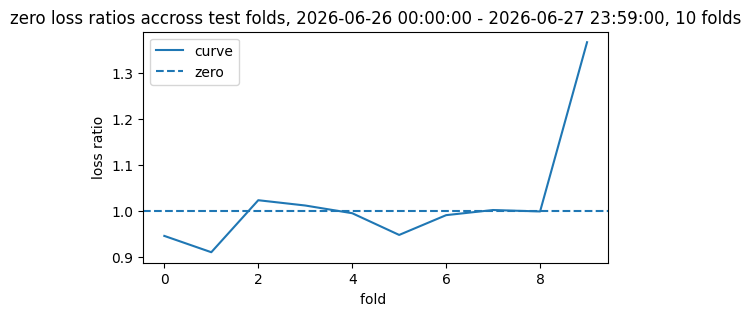

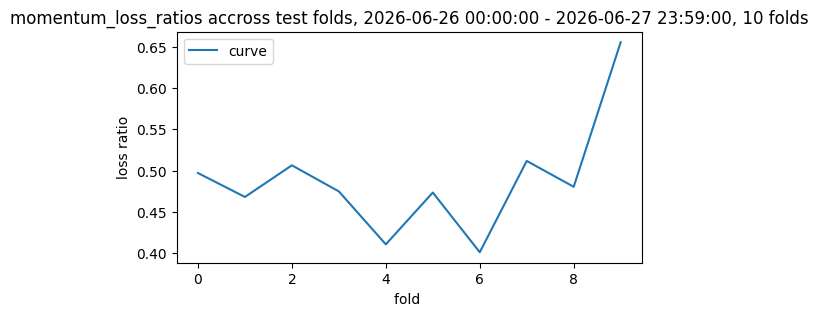

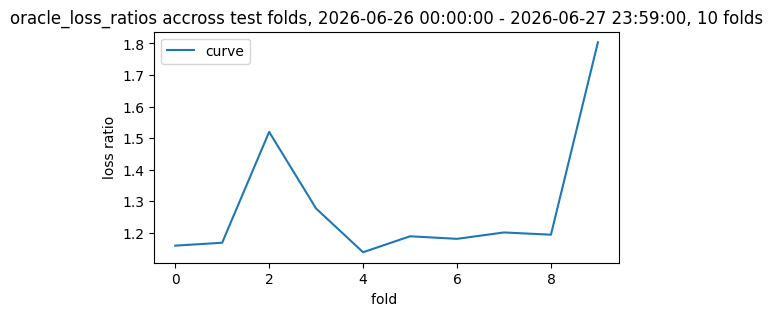

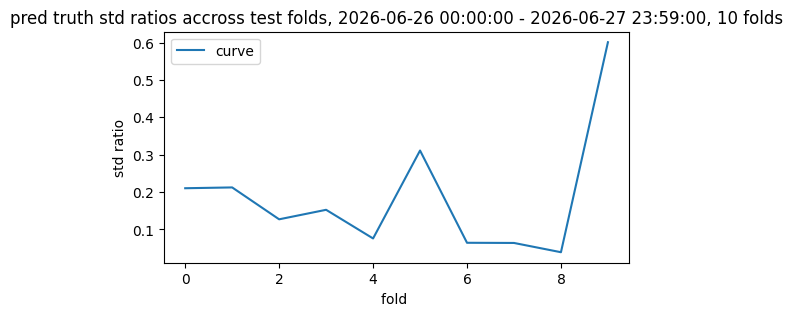

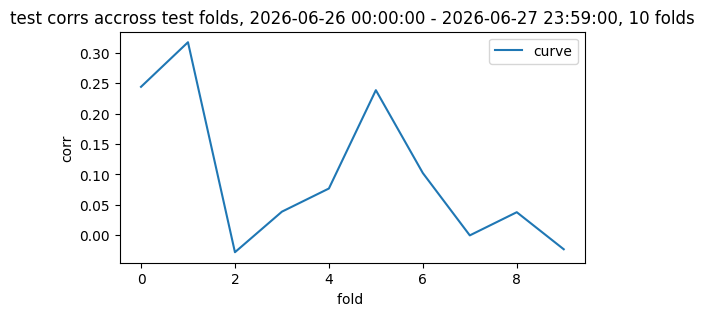

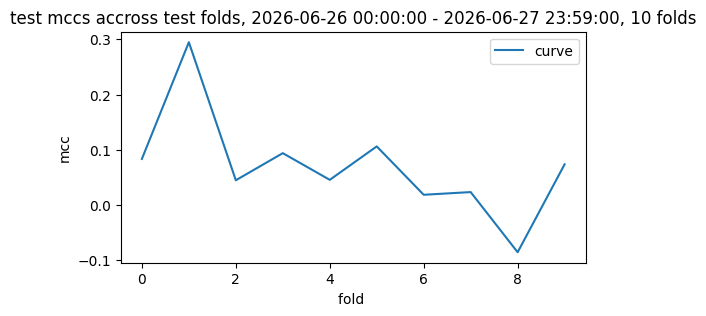

In [88]:
data_start_datetime = pd.Timestamp("2026-06-15 00:00:00", tz="UTC")
first_test_fold_start_datetime = pd.Timestamp("2026-06-26 00:00:00", tz="UTC")
data_end_datetime = pd.Timestamp("2026-06-27 23:59:00", tz="UTC")
n_test_folds = 10

lookback = 60
horizon = 1
interval = "1m"
target_symbol_idx = 0
threshold_percentile=90





test_zero_loss_ratios, momentum_loss_ratios, oracle_loss_ratios, test_pred_truth_std_ratios, test_corrs, test_mccs = \
    walk_forward_single_setup(data_start_datetime, data_end_datetime,
                            first_test_fold_start_datetime, n_test_folds,
                            lookback, horizon,
                            interval, target_symbol_idx,
                            val_ratio,
                            threshold_percentile, verbose=True)



plot_curves(f"zero loss ratios accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                [test_zero_loss_ratios], ["curve"], "fold ", "loss ratio",
                baseline_values=[1],
                baseline_labels=["zero"])

plot_curves(f"momentum_loss_ratios accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                [momentum_loss_ratios], ["curve"], "fold ", "loss ratio",
                baseline_values=[],
                baseline_labels=[])

plot_curves(f"oracle_loss_ratios accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                [oracle_loss_ratios], ["curve"], "fold ", "loss ratio",
                baseline_values=[],
                baseline_labels=[])



plot_curves(f"pred truth std ratios accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                [test_pred_truth_std_ratios], ["curve"], "fold ", "std ratio",
                baseline_values=[],
                baseline_labels=[])

plot_curves(f"test corrs accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                [test_corrs], ["curve"], "fold ", "corr",
                baseline_values=[],
                baseline_labels=[])

plot_curves(f"test mccs accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                [test_mccs], ["curve"], "fold ", "mcc",
                baseline_values=[],
                baseline_labels=[])




# Findings

- **Signal exists at horizon 1, and only there.** Test correlation is positive at horizon 1
  for every lookback in the grid (0.087–0.112). At horizons 5–40 correlations flip sign in a
  way consistent with noise. The predictable component is one bar deep.
- **BTC in the feature set helps, notably.** Runs with and without BTC features show a clear
  degradation when it's removed — the small-cap's next-bar move is partly explained by
  market-wide beta, not just its own microstructure.
- **The effect is not a seed artifact.** Metrics are stable across weight initializations
  and RNG seeds; fold-to-fold variation dominates seed variation by a wide margin.
- **The edge is real but tiny.** ~2 bps gross per trade, against a 15 bps cost floor.

# Conclusion

**Setup.** LSTM on 1-minute Binance bars, predicting next-bar return of CRCLBUSDT from a
cross-sectional feature set. Lookback (60) and horizon (1) selected on a grid search over
2026-06-24 → 2026-06-25; the walk-forward runs on 2026-06-26 → 2026-06-27, a window not used
for selection. Rolling (non-expanding) walk-forward, 10 folds, refit each fold.

**Selection rule.** Buy when the prediction exceeds the 90th percentile of the model's own
validation predictions — fitted on validation, frozen before test, chosen **without reference
to transaction costs**. That independence matters: the measured edge is not an artifact of
tuning the rule against the cost it's later compared to.

**Result (10 folds, 284 trades).**

| | selected | unconditional |
|---|---|---|
| mean return | **+2.27 bps** | +0.22 bps |
| % positive | 62.7% | 51.9% |
| n | 284 trades | 2,879 bars |

Conditional edge **+2.05 bps**, SE 0.83 bps (t = 2.73), positive in 8/10 folds.

**Costs.** Binance taker is 7.5 bps/side → **15 bps round-trip** against a one-minute hold.
Net **−12.73 bps** per trade: short of the cost floor by ~6×. No threshold rescues this — a
stricter cutoff gives fewer trades at only marginally better expected return.

**Verdict: statistically detectable, economically dead.**

# Caveats

- **Close prices only.** Returns are close-to-close, implicitly assuming fills at mid with
  zero spread and infinite depth. A taker order crosses the spread, and CRCLBUSDT is a
  small-cap pair where spread and top-of-book depth are both material at 1-minute frequency.
  The 15 bps fee is a *lower bound* on true cost; realistic execution widens the gap.
- **Threshold instability.** Trades per fold range 4–55 where a 90th-percentile rule should
  give ~29 — the validation threshold doesn't transport cleanly across folds.
- **t is optimistic.** It treats trades as iid; they cluster in time.
- **Narrow scope.** One symbol, two-day walk-forward. The horizon-1 effect appeared in two of
  three configuration-search windows and was absent in a third.
- **No output calibration.** Predictions are MSE-shrunk (pred/target std ≈ 0.1–0.2). Realized
  returns are unaffected, but the MSE-vs-zero-baseline ratios should be read with that in mind.

# Improvements

- **Richer features.** The inputs are candle-to-candle returns only — no volume, no
  volatility, no order-flow proxies. The LSTM can in principle build its own state from a
  return sequence, so this is less limiting than it would be for a feedforward model, but
  it leaves obvious information on the table.
- **Order-book data**, without which the cost conclusion can't be tightened.
- **Cross-sectional extension.** Longer horizons are closed off (no signal at 5–40), so the
  only route to a tradeable version is breadth: if the horizon-1 effect replicates across many
  symbols, a market-neutral basket with lower turnover per unit of signal becomes arguable.

#Appendix: RNG stability investigation

Metrics (loss ratio, correlation, MCC, prediction/truth std ratio) show meaningful variance across the 10 walk-forward folds, with several folds exhibiting weak or inverted directional skill (e.g., negative MCC).

To determine whether this variance originated from training randomness (different weight initializations, optimization paths and other RNG components) rather than the underlying data, we re-ran each fold 5 times with different random seeds, holding all other parameters fixed. Results were nearly identical across seeds for every fold (overlapping loss ratio, correlation, MCC, and std-ratio curves), confirming that the observed fold-to-fold variance is structural — driven by changes in market conditions across folds — rather than an artifact of training instability or random initialization.

This rules out one major confound and indicates that any instability in the signal reflects genuine regime-dependence in the underlying data, which we investigate next.

Same experiment but accross different model initializations and rng seeds, to check if results can be attributed to rng or are genuine

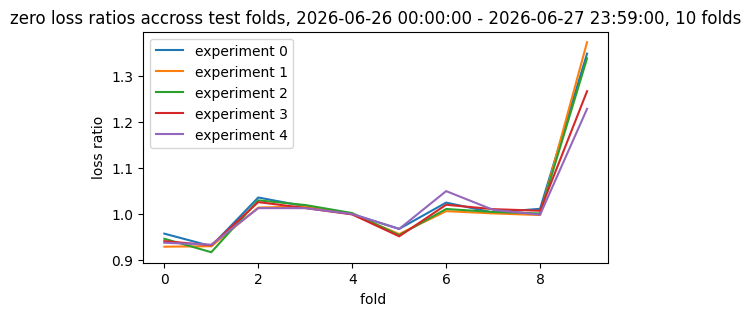

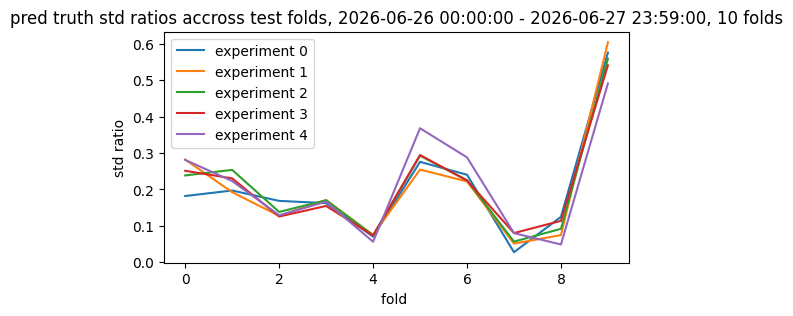

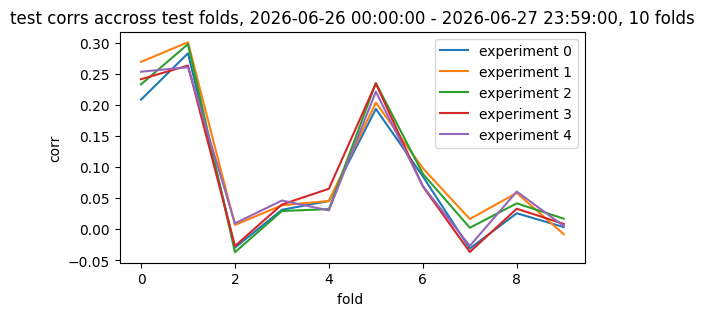

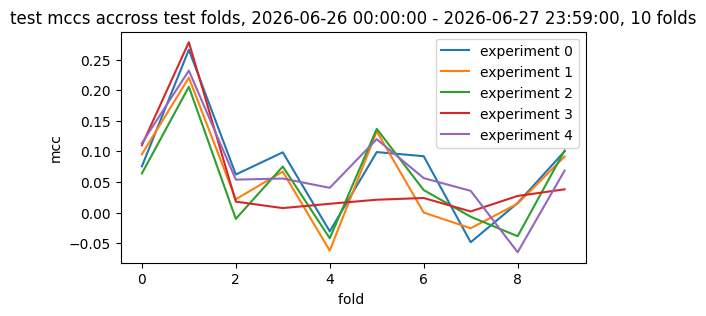

In [87]:
data_start_datetime = pd.Timestamp("2026-06-15 00:00:00", tz="UTC")
first_test_fold_start_datetime = pd.Timestamp("2026-06-26 00:00:00", tz="UTC")
data_end_datetime = pd.Timestamp("2026-06-27 23:59:00", tz="UTC")
n_test_folds = 10

threshold_percentile=90

lookback = 60
horizon = 1
interval = "1m"
target_symbol_idx = 0



test_zero_loss_ratios_curves = []
test_pred_truth_std_ratios_curves = []
test_corrs_curves = []
test_mccs_curves = []


for i in range(5):
    test_zero_loss_ratios, momentum_loss_ratios, oracle_loss_ratios, test_pred_truth_std_ratios, test_corrs, test_mccs = \
     walk_forward_single_setup(data_start_datetime, data_end_datetime,
                                first_test_fold_start_datetime, n_test_folds,
                                lookback, horizon,
                                interval, target_symbol_idx,
                                val_ratio,
                                threshold_percentile, verbose=False)

    test_zero_loss_ratios_curves.append(test_zero_loss_ratios)
    test_pred_truth_std_ratios_curves.append(test_pred_truth_std_ratios)
    test_corrs_curves.append(test_corrs)
    test_mccs_curves.append(test_mccs)


plot_curves(f"zero loss ratios accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                test_zero_loss_ratios_curves, [f"experiment {i}" for i in range(5)], "fold ", "loss ratio",
                baseline_values=[],
                baseline_labels=[])

plot_curves(f"pred truth std ratios accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                test_pred_truth_std_ratios_curves, [f"experiment {i}" for i in range(5)], "fold ", "std ratio",
                baseline_values=[],
                baseline_labels=[])

plot_curves(f"test corrs accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                test_corrs_curves, [f"experiment {i}" for i in range(5)], "fold ", "corr",
                baseline_values=[],
                baseline_labels=[])

plot_curves(f"test mccs accross test folds, {first_test_fold_start_datetime.strftime("%Y-%m-%d %H:%M:%S")} - {data_end_datetime.strftime("%Y-%m-%d %H:%M:%S")}, {n_test_folds} folds",
                test_mccs_curves, [f"experiment {i}" for i in range(5)], "fold ", "mcc",
                baseline_values=[],
                baseline_labels=[])


